# Lab 7B — Attention & a Minimal GPT

## From One Formula to a Language Model: ATTEND → STACK → TRAIN → GENERATE

### 🎯 Lab Philosophy

Lab 7A ended on a failure: static representations can't read *context* — "removing accommodation" scored as dovish. This lab builds the mechanism that fixes it. Every equation comes from **Lecture 7** (T3a Attention, T3b Transformer), implemented small enough to read in one sitting and train on a laptop CPU — the same architecture as GPT-2, at 1/2000th the size.

| Lab part | You build | Lecture 7 topic |
|---|---|---|
| Part 1 | scaled dot-product attention, 5 steps, by hand | T3a — the worked FOMC example |
| Part 2 | causal mask, multi-head, attention entropy | T3a — the machinery of GPT |
| Part 3 | a full Transformer block, stacked into a GPT | T3b — the architecture |
| Part 4 | the training loop (autoregressive LM loss) | T3b/T4 — pretraining |
| Part 5 | text generation with temperature & top-k | T4 — sampling |

### 🌐 Running this notebook (offline-safe)

- **No internet, no GPU, no API key.** Data is the bundled FOMC statement corpus from Lab 7A (`data/fomc/`). Training the mini-GPT takes **~10 minutes on a laptop CPU** (set `FAST_MODE = True` in Part 4 for a ~2-minute smoke run).
- Packages: `numpy`, `matplotlib`, `torch` (CPU build is fine). If missing:
  `pip install -i https://pypi.tuna.tsinghua.edu.cn/simple torch numpy matplotlib`
- Run cells **top to bottom**. ✏️ marks the three exercises (reference solutions in the Appendix).

> **Prerequisite:** Lab 7A (concepts: tokens, embeddings, cosine). The code here is self-contained.

In [1]:
# Quick environment check — run me first
import math
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

if not Path("fomc_data.py").exists():
    raise RuntimeError("Start this notebook from the Lec07_LLM_Lab folder (it contains fomc_data.py).")

from fomc_data import load_statements, corpus_summary

torch.manual_seed(0)
np.random.seed(0)
torch.set_num_threads(min(4, os.cpu_count() or 1))   # CPU-friendly: avoid thread oversubscription

BLUE, RED, GRAY = "#2a78d6", "#e34948", "#52514e"
plt.rcParams.update({
    "figure.figsize": (9, 3.2), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "lines.linewidth": 1.8,
})

statements = load_statements()
print("torch", torch.__version__, "| corpus:", corpus_summary(statements))

torch 2.8.0+cu128 | corpus: {'n_statements': 245, 'total_chars': 568478, 'first_date': '1994-02-04', 'last_date': '2026-06-17', 'avg_chars': 2320}


---

## Part 1 — Attention in 5 steps, by hand

**You are here:** `ATTEND` → stack → train → generate

The lecture's running example (T3a): the 9-token sentence

> **The**(1) **central**(2) **bank**(3) **raised**(4) **interest**(5) **rates**(6) **amid**(7) **rising**(8) **inflation**(9)

What should the vector for token 5, *interest*, mean here? Not "hobby", not "stake in a company" — *the thing you pay on borrowed money, currently being raised*. Attention builds that meaning by letting *interest* **read the other tokens, weighted by relevance**. Five steps (lecture notation):

| Step | Formula | In words |
|---|---|---|
| 1 | $Q_i = W_Q e^{(i)},\; K_i = W_K e^{(i)},\; V_i = W_V e^{(i)}$ | each token asks (query), advertises (key), offers (value) |
| 2 | $s_j^{(i)} = \langle Q_i, K_j\rangle / \sqrt{k}$ | how much should $i$ listen to $j$? ($\sqrt{k}$ keeps variance $\approx 1$) |
| 3 | $\alpha_j^{(i)} = \mathrm{softmax}_j\big(s_j^{(i)}\big)$ | scores → shares of attention, $\sum_j \alpha_j^{(i)} = 1$ |
| 4 | $\mathrm{AttnVec}_i = \sum_j \alpha_j^{(i)} V_j$ | a weighted *blend* of what the other tokens offer |
| 5 | $\tilde{e}^{(i)} = W_O\, \mathrm{AttnVec}_i$ | project back to model space |

### Step 1 — The slide's numbers, verified

The T3a slides suppose the trained model produces these scaled scores $s_j^{(5)}$ for the query token *interest*. We apply Step 3 (softmax) to them and print the exact weights — compare with the slide's rounded ≈0.50 / 0.40 / 0.05 (the ranking and the story are identical; the slide compresses the tail):

In [2]:
tokens = ["The", "central", "bank", "raised", "interest", "rates", "amid", "rising", "inflation"]

# scaled attention scores for query token 5 = "interest", from the T3a slide
slide_scores = {"rates": 2.3, "inflation": 1.9, "raised": 1.1, "bank": 0.5, "the": -0.2}

def softmax(x):
    e = np.exp(x - np.max(x))          # subtract max: numerical stability
    return e / e.sum()

alpha = softmax(np.array(list(slide_scores.values())))
print("attention of 'interest' over the sentence:")
for (tok, s), a in zip(slide_scores.items(), alpha):
    print(f"   {tok:>10s}   score {s:+.1f}   ->   weight {a:.2f}")
print(f"{'':>26s}  sum = {alpha.sum():.2f}")

attention of 'interest' over the sentence:
        rates   score +2.3   ->   weight 0.45
    inflation   score +1.9   ->   weight 0.30
       raised   score +1.1   ->   weight 0.14
         bank   score +0.5   ->   weight 0.07
          the   score -0.2   ->   weight 0.04
                            sum = 1.00


Half the attention goes to *rates*, most of the rest to *inflation* — the words that pin down what *interest* means **in this sentence**. Step 4 then blends the value vectors: $\mathrm{AttnVec}_5 \approx 0.45\,V_6 + 0.30\,V_9 + 0.14\,V_4 + \dots$ — and Step 5 projects the blend back. The result $\tilde{e}^{(5)}$ is *"interest, in a context dominated by rates and inflation"*. Swap the sentence to *"The discount rates applied to pension funds…"* and the same machinery would shift the weights to *discount* and *pension* — **one set of matrices, context-dependent meaning**. That is what no static embedding in Lab 7A could do.

### Step 2 — All five steps, in code

input X: (9, 16), output: (9, 16) — same shape in, same shape out
attention matrix A: (9, 9), every row sums to 1: True


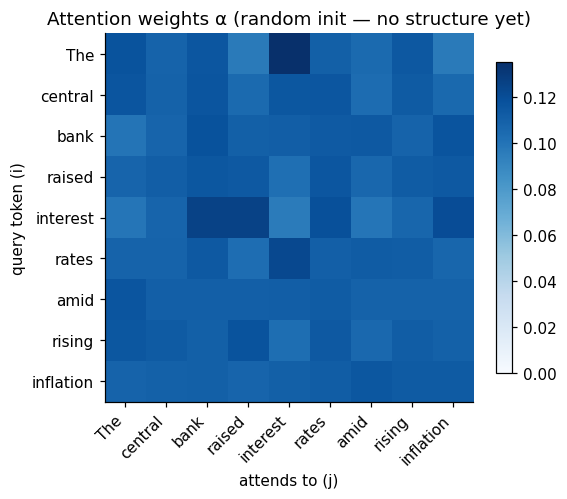

In [3]:
def attention_5steps(X, W_Q, W_K, W_V, W_O):
    """Self-attention exactly as on the T3a slides. X: (n, d) token embeddings."""
    Q = X @ W_Q.T                                   # step 1: queries   (n, k)
    K = X @ W_K.T                                   #         keys      (n, k)
    V = X @ W_V.T                                   #         values    (n, k)
    k = Q.shape[1]
    S = Q @ K.T / np.sqrt(k)                        # step 2: scaled scores  (n, n)
    A = np.apply_along_axis(softmax, 1, S)          # step 3: weights, rows sum to 1
    AttnVec = A @ V                                 # step 4: weighted blend (n, k)
    return AttnVec @ W_O.T, A                       # step 5: back to (n, d)

n, d, k = len(tokens), 16, 8                        # tiny dims so we can stare at them
rng = np.random.default_rng(0)
X = rng.normal(size=(n, d)) / np.sqrt(d)            # stand-in embeddings
W_Q, W_K, W_V = (rng.normal(size=(k, d)) / np.sqrt(d) for _ in range(3))
W_O = rng.normal(size=(d, k)) / np.sqrt(k)

out, A = attention_5steps(X, W_Q, W_K, W_V, W_O)
print(f"input X: {X.shape}, output: {out.shape} — same shape in, same shape out")
print(f"attention matrix A: {A.shape}, every row sums to 1: {np.allclose(A.sum(1), 1)}")

fig, ax = plt.subplots(figsize=(5.4, 4.6))
im = ax.imshow(A, cmap="Blues", vmin=0)
ax.set_xticks(range(n), tokens, rotation=45, ha="right")
ax.set_yticks(range(n), tokens)
ax.set_xlabel("attends to (j)"); ax.set_ylabel("query token (i)")
ax.set_title("Attention weights α (random init — no structure yet)")
ax.grid(False)
fig.colorbar(im, shrink=0.8)
plt.show()

With random matrices the weights are near-uniform mush — **attention patterns are learned, not built in**. Part 4 will train them; then we'll look again.

### ✏️ Your turn — B1: `scaled_dot_attention`

Write the core as one reusable function and verify it by hand on a 2-token case:

```python
def scaled_dot_attention(Q, K, V):
    """Q, K, V: (n, k) arrays -> (attention output (n, k), weights (n, n))."""
```

Check: with $Q = K = V = \begin{pmatrix} 1 & 0 \\ 0 & 1 \end{pmatrix}$ (so $k=2$), the scores are $S = \frac{1}{\sqrt 2}I$, each row's softmax is $(\sigma, 1-\sigma)$ with $\sigma = \frac{e^{1/\sqrt 2}}{e^{1/\sqrt 2} + 1} \approx 0.670$ — compute that number on paper, then `assert` your function reproduces it. *(Solution in the Appendix.)*

In [4]:
# ✏️ B1 — your code here
def scaled_dot_attention(Q, K, V):
    ...


---

## Part 2 — Causal masking, multiple heads, and an entropy diagnostic

**Causal mask.** A language model predicts the *next* token, so token $i$ must not peek at tokens $j > i$ — at generation time those tokens don't exist yet. The fix is brutal and elegant: set future scores to $-\infty$ before the softmax, so their weight is exactly 0. The mask is a lower-triangular matrix.

**Multi-head.** One attention pattern per layer is too little — *interest* might need syntax from *raised* AND semantics from *inflation*. Split $d$ into $H$ heads of size $k = d/H$; each head runs the same 5 steps with its own $W_Q, W_K, W_V$; concatenate and project. Different heads learn different relations.

**Entropy diagnostic.** Is a head focused or diffuse? The lecture's measure: $H(\alpha^{(i)}) = -\sum_j \alpha_j^{(i)} \log \alpha_j^{(i)}$ — 0 means all attention on one token, $\log n$ means uniform. We'll use it on the trained model in Part 5.

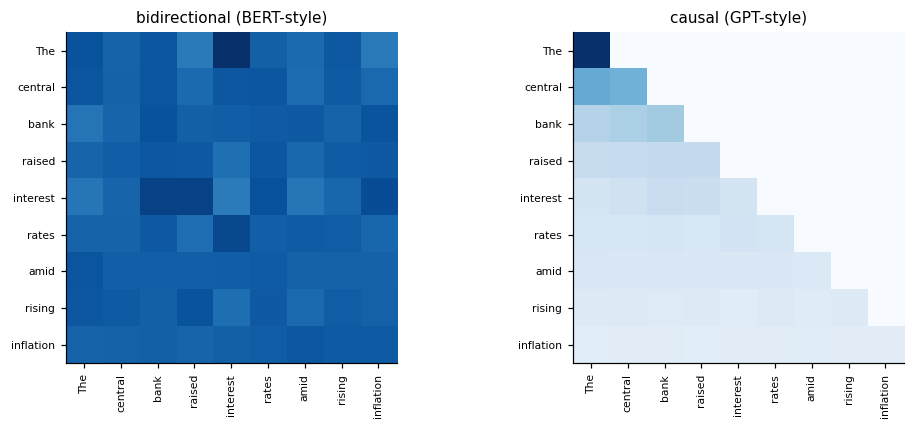

entropy of 'inflation' row (sees all 9 tokens): 2.20   (max = ln 9 = 2.20)
entropy of 'The' row (sees only itself):        -0.00   (fully determined)


In [5]:
def causal_scores(S):
    """Mask future positions: S[i, j] = -inf for j > i."""
    n = S.shape[0]
    return np.where(np.tril(np.ones((n, n), dtype=bool)), S, -np.inf)

S_demo = X @ W_Q.T @ (X @ W_K.T).T / np.sqrt(k)
A_masked = np.apply_along_axis(softmax, 1, causal_scores(S_demo))

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.0))
for ax, M, title in [(axes[0], A, "bidirectional (BERT-style)"),
                     (axes[1], A_masked, "causal (GPT-style)")]:
    ax.imshow(M, cmap="Blues", vmin=0)
    ax.set_xticks(range(n), tokens, rotation=90, fontsize=7)
    ax.set_yticks(range(n), tokens, fontsize=7)
    ax.set_title(title, fontsize=10)
    ax.grid(False)
plt.tight_layout(); plt.show()

def attention_entropy(row):
    p = row[row > 0]
    return float(-(p * np.log(p)).sum())

print(f"entropy of 'inflation' row (sees all 9 tokens): {attention_entropy(A_masked[8]):.2f}   (max = ln 9 = {np.log(9):.2f})")
print(f"entropy of 'The' row (sees only itself):        {attention_entropy(A_masked[0]):.2f}   (fully determined)")

The upper triangle of the causal matrix is exactly zero — *raised* cannot read *inflation*, because when the model is generating token 4, token 9 hasn't been written yet. This single constraint is what makes the transformer a **generative** model: it turns attention into a next-token machine.

### ✏️ Your turn — B2: `causal_mask`

Implement `causal_mask(T)` returning a `(T, T)` boolean lower-triangular matrix **in PyTorch** (`torch.tril` + `torch.ones` is enough — we'll use it in the GPT next). Verify: masked-softmax of a random score matrix puts zero weight above the diagonal, and row 0 attends 100% to itself. *(Solution in the Appendix.)*

In [6]:
# ✏️ B2 — your code here
def causal_mask(T):
    ...


---

## Part 3 — A minimal GPT

**You are here:** attend → `STACK` → train → generate

One transformer **block** (T3b, pre-LayerNorm variant used by GPT-2):

$$u^{(i)} = e^{(i)} + \mathrm{MHAttn}(\mathrm{Norm}(e))^{(i)}, \qquad e'^{(i)} = u^{(i)} + \mathrm{FFN}(\mathrm{Norm}(u))^{(i)}, \qquad \mathrm{FFN}(x) = W_2\, \mathrm{GELU}(W_1 x + b_1) + b_2$$

with $W_1: d \to 4d$ (expand) and $W_2: 4d \to d$ (contract). Stack $L$ blocks, add token + position embeddings at the bottom and a linear head $W_{vocab} \in \mathbb{R}^{M \times d}$ at the top, and that *is* GPT.

**Tokens: characters.** Real GPTs use BPE (Lab 7A); we use single characters so the whole vocabulary fits in one `print` and the model must genuinely *learn* spelling, words, and phrasing from scratch — watching that happen is the point of the lab.

In [7]:
# ---- character tokenizer over the FOMC corpus ----
text = "\n\n".join(t for _, t in statements)
chars = sorted(set(text))
M = len(chars)                                   # vocabulary size (lecture: M)
stoi = {c: i for i, c in enumerate(chars)}
itos = {i: c for c, i in stoi.items()}
enc = lambda s: torch.tensor([stoi[c] for c in s], dtype=torch.long)
dec = lambda ids: "".join(itos[int(i)] for i in ids)

print(f"corpus: {len(text):,} characters, vocabulary M = {M}:")
print("".join(chars).replace("\n", "⏎"))

# train / validation split: every 20th statement is held out (spread across eras)
val_text = "\n\n".join(t for i, (_, t) in enumerate(statements) if i % 20 == 0)
train_text = "\n\n".join(t for i, (_, t) in enumerate(statements) if i % 20 != 0)
train_ids, val_ids = enc(train_text), enc(val_text)
print(f"train {len(train_ids):,} chars | val {len(val_ids):,} chars")

corpus: 568,966 characters, vocabulary M = 78:
⏎ "$'(),-./0123456789:;ABCDEFGHIJKLMNOPQRSTUVWYabcdefghijklmnopqrstuvwxyz‑–—’�
train 537,303 chars | val 31,661 chars


In [8]:
# ---- the model: dims in lecture notation ----
D_MODEL = 128        # d  — model / embedding dimension
N_HEADS = 4          # H  — heads, so k = d/H = 32
N_LAYERS = 3         # L  — stacked blocks
CONTEXT = 128        # n  — max sequence length the model can see
DROPOUT = 0.1

class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d, H, n_ctx):
        super().__init__()
        assert d % H == 0
        self.H, self.k = H, d // H
        self.qkv = nn.Linear(d, 3 * d)                       # W_Q, W_K, W_V for all heads at once
        self.proj = nn.Linear(d, d)                          # W_O
        self.drop = nn.Dropout(DROPOUT)
        self.register_buffer("mask", torch.tril(torch.ones(n_ctx, n_ctx)).bool())

    def forward(self, x):                                    # x: (B, T, d)
        B, T, d = x.shape
        q, k, v = self.qkv(x).split(d, dim=2)
        # reshape to (B, H, T, k): every head attends independently
        q, k, v = (z.view(B, T, self.H, self.k).transpose(1, 2) for z in (q, k, v))
        S = q @ k.transpose(-2, -1) / math.sqrt(self.k)      # step 2: (B, H, T, T)
        S = S.masked_fill(~self.mask[:T, :T], float("-inf")) # causal mask (Part 2)
        A = F.softmax(S, dim=-1)                             # step 3
        out = A @ v                                          # step 4
        out = out.transpose(1, 2).contiguous().view(B, T, d) # concat heads
        return self.drop(self.proj(out)), A                  # step 5 (+ weights for diagnostics)

class Block(nn.Module):
    def __init__(self, d, H, n_ctx):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.attn = MultiHeadSelfAttention(d, H, n_ctx)
        self.ffn = nn.Sequential(                            # W_1: d -> 4d, GELU, W_2: 4d -> d
            nn.Linear(d, 4 * d), nn.GELU(), nn.Linear(4 * d, d), nn.Dropout(DROPOUT))

    def forward(self, x):
        a, A = self.attn(self.ln1(x))
        x = x + a                                            # residual 1
        x = x + self.ffn(self.ln2(x))                        # residual 2
        return x, A

class MiniGPT(nn.Module):
    def __init__(self, M, d=D_MODEL, H=N_HEADS, L=N_LAYERS, n_ctx=CONTEXT):
        super().__init__()
        self.tok_emb = nn.Embedding(M, d)                    # E: {1..M} -> R^d
        self.pos_emb = nn.Embedding(n_ctx, d)                # learned p(i)
        self.blocks = nn.ModuleList(Block(d, H, n_ctx) for _ in range(L))
        self.ln_f = nn.LayerNorm(d)
        self.head = nn.Linear(d, M, bias=False)              # W_vocab: R^{M x d}
        self.n_ctx = n_ctx

    def forward(self, idx, return_attn=False):               # idx: (B, T) token IDs
        B, T = idx.shape
        x = self.tok_emb(idx) + self.pos_emb(torch.arange(T))   # e^(i) = E(t^(i)) + p(i)
        attns = []
        for block in self.blocks:
            x, A = block(x)
            attns.append(A)
        logits = self.head(self.ln_f(x))                     # (B, T, M)
        return (logits, attns) if return_attn else logits

model = MiniGPT(M)
n_params = sum(p.numel() for p in model.parameters())
print(f"MiniGPT: d={D_MODEL}, H={N_HEADS} (k={D_MODEL//N_HEADS}), L={N_LAYERS}, n={CONTEXT}, M={M}")
print(f"parameters: {n_params:,}")
print(f"\nfor scale (T3b table): GPT-2 has L=12-48, d=768-1600, n=1024, M≈50k -> 0.1-1.5B params")
print(f"our model is ~{1.5e9 / n_params:,.0f}x smaller than GPT-2-XL — same architecture")

MiniGPT: d=128, H=4 (k=32), L=3, n=128, M=78
parameters: 631,424

for scale (T3b table): GPT-2 has L=12-48, d=768-1600, n=1024, M≈50k -> 0.1-1.5B params
our model is ~2,376x smaller than GPT-2-XL — same architecture


---

## Part 4 — Training: the autoregressive objective

**You are here:** attend → stack → `TRAIN` → generate

The entire training signal is the lecture's one formula (T3a/T4) — maximize the probability of each next token given its prefix:

$$\mathcal{L}(\theta) = -\sum_s \sum_i \log P_\theta\big(t_s^{(i+1)} \,\big|\, t_s^{(1:i)}\big)$$

No labels, no annotation — the text is its own supervision (*self-supervised learning*). Each batch: grab 32 random 128-character windows, predict every character from the ones before it.

**What to expect.** Loss starts near $\ln M \approx 4.6$ (uniform guessing over the vocabulary) and falls **below 1 nat/char** — unusually low for a char model, because FOMC prose is extremely formulaic. The model climbs from "random keystrokes" through "English letter frequencies" to "FOMC house style"; watch the samples printed during training to see that climb happen live.

> `FAST_MODE = True` runs 600 steps (~2 min) instead of 3000 (~10 min) — fine for a class demo; the committed outputs below are from the full run.

In [9]:
FAST_MODE = False                     # True -> ~2 min smoke run; False -> the real thing (~10 min CPU)

MAX_STEPS = 600 if FAST_MODE else 3000
EVAL_EVERY = 100 if FAST_MODE else 250
BATCH, LR, WARMUP, CLIP = 32, 3e-4, 100, 1.0

def get_batch(ids):
    """32 random context windows and their next-char targets."""
    starts = torch.randint(0, len(ids) - CONTEXT - 1, (BATCH,))
    x = torch.stack([ids[s: s + CONTEXT] for s in starts])
    y = torch.stack([ids[s + 1: s + CONTEXT + 1] for s in starts])
    return x, y

@torch.no_grad()
def eval_loss(ids, n_batches=25):
    model.eval()
    losses = []
    for _ in range(n_batches):
        x, y = get_batch(ids)
        logits = model(x)
        losses.append(F.cross_entropy(logits.view(-1, M), y.view(-1)).item())
    model.train()
    return float(np.mean(losses))

@torch.no_grad()
def sample(prompt="The Committee decided", n_new=150, temperature=0.8):
    """Autoregressive generation: predict, sample, append, repeat."""
    model.eval()
    idx = enc(prompt)[None, :]
    for _ in range(n_new):
        logits = model(idx[:, -CONTEXT:])[0, -1] / temperature
        nxt = torch.multinomial(F.softmax(logits, dim=-1), 1)
        idx = torch.cat([idx, nxt[None, :]], dim=1)
    model.train()
    return dec(idx[0])

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
sched = torch.optim.lr_scheduler.LambdaLR(optimizer, lambda s: min(1.0, (s + 1) / WARMUP))

train_curve, val_curve = [], []
import time
t0 = time.time()
for step in range(1, MAX_STEPS + 1):
    x, y = get_batch(train_ids)
    logits = model(x)
    loss = F.cross_entropy(logits.view(-1, M), y.view(-1))
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), CLIP)
    optimizer.step()
    sched.step()
    train_curve.append((step, loss.item()))
    if step % EVAL_EVERY == 0 or step == 1:
        vl = eval_loss(val_ids)
        val_curve.append((step, vl))
        print(f"step {step:5d} | train {loss.item():.3f} | val {vl:.3f} | {time.time()-t0:5.0f}s")
        if step in (EVAL_EVERY, MAX_STEPS):
            print(f'   sample: "{sample(n_new=100)}"')
print(f"\ndone in {(time.time()-t0)/60:.1f} min")

step     1 | train 4.525 | val 4.516 |     3s


step   250 | train 2.443 | val 2.399 |    52s


   sample: "The Committee decided mingatontiomee f t te f inge gomononthero ioming fkelito rrskepho wtind e Che icon conds e preran r"


step   500 | train 2.302 | val 2.246 |   100s


step   750 | train 1.976 | val 1.936 |   149s


...

step  2250 | train 1.074 | val 0.853 |   427s


step  2500 | train 0.887 | val 0.815 |   470s


step  2750 | train 0.807 | val 0.754 |   516s


step  3000 | train 0.745 | val 0.728 |   561s


   sample: "The Committee decided to continue to returning to beginal rective. Market is since declined to be the Committee stability"

done in 9.3 min


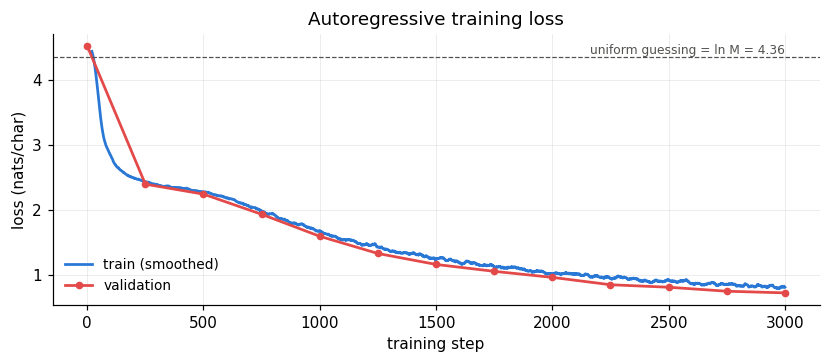

validation loss: 4.516 -> 0.728
✓ the model learned — and it never saw the validation statements


In [10]:
steps_t, loss_t = zip(*train_curve)
steps_v, loss_v = zip(*val_curve)

smooth = np.convolve(loss_t, np.ones(20) / 20, mode="valid")   # 20-step moving average

fig, ax = plt.subplots()
ax.plot(steps_t[19:], smooth, color=BLUE, label="train (smoothed)")
ax.plot(steps_v, loss_v, "o-", ms=4, color=RED, label="validation")
ax.axhline(np.log(M), color=GRAY, lw=0.8, ls="--")
ax.annotate(f"uniform guessing = ln M = {np.log(M):.2f}", (steps_t[-1], np.log(M)),
            ha="right", va="bottom", fontsize=8, color=GRAY)
ax.set_xlabel("training step"); ax.set_ylabel("loss (nats/char)")
ax.set_title("Autoregressive training loss")
ax.legend(frameon=False, fontsize=9)
plt.show()

first_val, final_val = loss_v[0], loss_v[-1]
print(f"validation loss: {first_val:.3f} -> {final_val:.3f}")
target = 2.6 if FAST_MODE else 2.0                # 600 steps only gets partway down the curve
assert final_val < first_val, "validation loss did not improve"
assert final_val < target, f"expected < {target} nats/char, got {final_val:.3f}"
print("✓ the model learned — and it never saw the validation statements")

Train and validation fall together — the model is learning *the language of FOMC statements*, not memorizing the training files (the validation statements were never seen — they're just written in the same house style). For scale: GPT-2 gets *general* English text to ≈1.0 bits/char with 1,500× more parameters and 100,000× more data — our tiny model only wins because this corpus is thirty years of highly repetitive committee prose. More data diversity ⇒ you need more model: the scaling laws of T4 start exactly here.

---

## Part 5 — Generation: temperature, and what the heads learned

**You are here:** attend → stack → train → `GENERATE`

Generation is the training loop's mirror: feed a prompt, take the predicted distribution for the next character, **sample** from it, append, repeat. The one knob is **temperature** $\tau$ — logits are divided by $\tau$ before the softmax (T4):

- $\tau \to 0$: always pick the argmax — safe, repetitive, deterministic (use for *measurement*)
- $\tau = 1$: sample from the model's honest distribution
- $\tau > 1$: flatten the distribution — creative, and increasingly unhinged

In [11]:
for tau in (0.5, 0.8, 1.2):
    print(f"--- temperature {tau} " + "-" * 50)
    print(sample("The Committee decided", n_new=280, temperature=tau))
    print()

--- temperature 0.5 --------------------------------------------------


The Committee decided to raise the target range for the federal funds rate by 201014 percent. In lon as prices of inflation expectations and the economic activity has continued to sustainable growth increase discount of the Federal Reserve Banks of Federal Reserve Banks of Board of Bank objective, Ri

--- temperature 0.8 --------------------------------------------------


The Committee decided to keep its target for the target range for the federal funds rate an extend progress of 2 percent over the federal funds rate at purchase stance of monetary policy accommodative is in the risks for the outlook. The Committee will continue to the outlook. The Committee continues

--- temperature 1.2 --------------------------------------------------


The Committee decided today to prices the Hergew L. L. Qderger-term inf clation, the Committee's eabolion su‑moutloy 2 percent. The payments its have bolev proved, the Committee at to levelow leaken to the outAdual, indicaging to maintain indate, inflation the policy aftersment underic, realiasures i



Every word of that came out of a 0.6M-parameter model we trained from random weights twenty minutes ago, one character at a time — it learned to spell *Committee*, open with the house phrasing, and close sentences, purely from the autoregressive objective. It also **makes up policy content** — smooth, confident, wrong. That is T5a's hallucination lesson at miniature scale: *the loss rewards plausible form, not truth*, which is why Lecture 8 adds retrieval.

### The heads, revisited

In Part 1, random-init attention was uniform mush. Now feed the trained model a sentence and look at one head per layer, plus the lecture's entropy diagnostic per head:

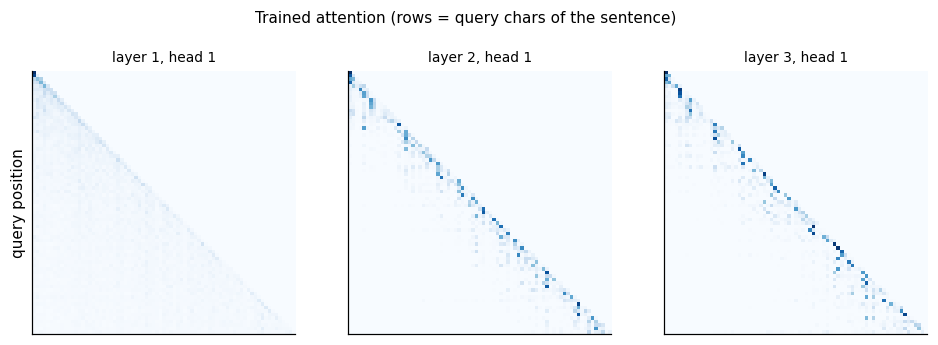

mean attention entropy per head (0 = focused, ln T = diffuse):
(T = 75 characters, ln T = 4.32)
  layer 1: head 1: 3.22  head 2: 3.30  head 3: 3.18  head 4: 3.29
  layer 2: head 1: 1.54  head 2: 1.84  head 3: 0.45  head 4: 1.77
  layer 3: head 1: 1.48  head 2: 1.73  head 3: 1.71  head 4: 1.70


In [12]:
sentence = "The Committee decided to raise the target range for the federal funds rate."
ids = enc(sentence)[None, :]
_, attns = model(ids, return_attn=True)              # attns: L x (1, H, T, T)

T = ids.shape[1]
fig, axes = plt.subplots(1, N_LAYERS, figsize=(10.5, 3.6))
for ell, ax in enumerate(axes):
    A_l = attns[ell][0, 0].detach().numpy()          # head 0 of layer ell
    ax.imshow(A_l, cmap="Blues", vmin=0)
    ax.set_title(f"layer {ell + 1}, head 1", fontsize=9)
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
axes[0].set_ylabel("query position")
fig.suptitle("Trained attention (rows = query chars of the sentence)", fontsize=10)
plt.show()

print("mean attention entropy per head (0 = focused, ln T = diffuse):")
print(f"(T = {T} characters, ln T = {np.log(T):.2f})")
for ell in range(N_LAYERS):
    ents = []
    for h in range(N_HEADS):
        A_l = attns[ell][0, h].detach().numpy()
        row_ents = [attention_entropy(A_l[i]) for i in range(1, T)]
        ents.append(np.mean(row_ents))
    print(f"  layer {ell + 1}: " + "  ".join(f"head {h+1}: {e:.2f}" for h, e in enumerate(ents)))

Typical result: some heads go **local** (a bright band along the diagonal — each character reads its immediate predecessors: spelling), others stay **diffuse** (high entropy — gathering broad context). Nobody told them to specialize; the division of labor emerges from the loss. This entropy table is the same diagnostic the lecture proposes for auditing *which* text a measurement model actually used.

### ✏️ Your turn — B3: top-k sampling

Pure temperature sampling occasionally picks a really bad character (there are M ≈ 90 options; even 1% tail risk compounds over hundreds of draws). **Top-k sampling** fixes the tail: keep only the $k$ highest logits, zero out the rest, then sample. Implement

```python
def sample_topk(prompt, n_new=280, temperature=0.8, k=10):
```

(hint: `torch.topk`, then set everything below the k-th logit to `-inf` before the softmax). Generate with `k=10` and compare with the $\tau = 1.2$ output above — same creativity, fewer derailments? *(Solution in the Appendix.)*

In [13]:
# ✏️ B3 — your code here
def sample_topk(prompt, n_new=280, temperature=0.8, k=10):
    ...


---

### Make it your own

- **Word-level GPT:** swap the character tokenizer for Lab 7A's word vocabulary (M ≈ 1,900) — same model, ~4× shorter sequences. Does sample quality improve at equal training time?
- **Scale one dial:** double `N_LAYERS` or `D_MODEL` and re-run. Where does the val curve land? You are tracing a Kaplan scaling curve (T4) with your own CPU.
- **Prompt the eras:** condition on `"In light of the coronavirus"` vs `"Chairman Alan Greenspan announced"` — the model has absorbed 30 years of house style; can you steer which decade it imitates?

### Wrap-up — the whole lab in one map

| You built | The formula | The lesson |
|---|---|---|
| 5-step attention | $\alpha = \mathrm{softmax}(QK^\top/\sqrt{k})$, blend $V$ | meaning from context, learned not hard-coded |
| causal mask | $s_j^{(i)} = -\infty$ for $j > i$ | one constraint turns attention into a generator |
| transformer block | attention + residual + Norm + FFN | the repeating unit of every modern LLM |
| training loop | $-\sum \log P_\theta(t^{(i+1)} \mid t^{(1:i)})$ | text is its own supervision |
| sampling | logits $/\tau$, top-k | fluent ≠ true — form is what the loss buys |

**Bridge to Lecture 8 / the RAG lab:** our mini-GPT writes fluent FOMC-ese but *invents the numbers* — it has style without facts. Scaling to GPT-4 size adds knowledge but never fixes the objective: likelihood rewards plausibility, not truth. The engineering answer is to **retrieve real documents and ground the generation in them** — which is exactly what you build in the Lecture 8 RAG lab.

---

## Appendix — Reference solutions

In [14]:
# B1 — scaled dot-product attention
def scaled_dot_attention(Q, K, V):
    """Q, K, V: (n, k) -> (output (n, k), weights (n, n))."""
    k_dim = Q.shape[1]
    S = Q @ K.T / np.sqrt(k_dim)
    A = np.apply_along_axis(softmax, 1, S)
    return A @ V, A

I2 = np.eye(2)
out2, A2 = scaled_dot_attention(I2, I2, I2)
sigma = np.exp(1 / np.sqrt(2)) / (np.exp(1 / np.sqrt(2)) + 1)
print(f"hand-computed sigma = {sigma:.3f}")
print("attention matrix:\n", A2.round(3))
assert np.allclose(A2, [[sigma, 1 - sigma], [1 - sigma, sigma]])
print("✓ matches the paper-and-pencil softmax")

hand-computed sigma = 0.670
attention matrix:
 [[0.67 0.33]
 [0.33 0.67]]
✓ matches the paper-and-pencil softmax


In [15]:
# B2 — causal mask in PyTorch
def causal_mask(T):
    return torch.tril(torch.ones(T, T)).bool()

S_rand = torch.randn(5, 5)
A_rand = F.softmax(S_rand.masked_fill(~causal_mask(5), float("-inf")), dim=-1)
print(A_rand.round(decimals=3))
assert torch.all(A_rand.triu(1) == 0), "future positions must get zero weight"
assert A_rand[0, 0] == 1.0, "the first token can only attend to itself"
print("✓ no token reads the future")

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.9040, 0.0960, 0.0000, 0.0000, 0.0000],
        [0.2590, 0.5100, 0.2310, 0.0000, 0.0000],
        [0.1040, 0.0960, 0.1960, 0.6040, 0.0000],
        [0.0380, 0.0800, 0.4440, 0.0410, 0.3970]])
✓ no token reads the future


In [16]:
# B3 — top-k sampling
@torch.no_grad()
def sample_topk(prompt="The Committee decided", n_new=280, temperature=0.8, k=10):
    model.eval()
    idx = enc(prompt)[None, :]
    for _ in range(n_new):
        logits = model(idx[:, -CONTEXT:])[0, -1] / temperature
        kth = torch.topk(logits, k).values[-1]
        logits[logits < kth] = float("-inf")          # kill the tail
        nxt = torch.multinomial(F.softmax(logits, dim=-1), 1)
        idx = torch.cat([idx, nxt[None, :]], dim=1)
    model.train()
    return dec(idx[0])

print(sample_topk(temperature=1.2, k=10))
# Compare with the tau=1.2 output in Part 5: same temperature, but the -inf'd tail
# means no rare-character derailments. GPT-style APIs expose exactly these knobs
# (temperature, top_k / top_p) — now you know what they do to the distribution.

The Committee decided to raise at a 125 percent to 4 2 percent. The Committee act relose increaging production. Household spently to be economic growths.

Recipal cumutoribs and the attenounded to its promote action will continue toward a remain stable.

To ic activity conditions, inducing in flation
